Data Exploration and Analysis | DSC-530 T301 <br>
Jeremy Barton <br>
07.04.2025

<b>Appendix</b>

[Introduction](#introduction)

[Data Preparation](#data-preparation)


## Introduction

In on ongoing journey to achieve food soverigenty, a program was developed to collect abiotic environment context surrounding biological organisms. Data such as this is helpful in exploring how external conditions correlate with internal biological progression.

A recent experiment was cut short after an unsuccessful transplant from indoor indubation to the outdoor greenhouse. All subjects, Lettuce, Radish, Tomato and Cilantro completed the germination phase sucessfully.

However, only one of four subjects survived the transplant phase. This analysis will focus on the Tomato plant, since it showed the most progress before failure. We will examine though, what may have caused the Cilantro to survive.

### Data Preparation

Read in the session data from the export directory. Checking the shape, both datasets are around the same size. 

In [1]:
# Imports and pre-processing
import pandas as pd
import matplotlib.pyplot as plt

# .read_csv() in the indoor and outdoor session data. (1 and 2 respectively)
sesh_a = pd.read_csv('/home/nunya/Documents/GitHub/AGT/journal/data/session1_data.csv')
sesh_b = pd.read_csv('/home/nunya/Documents/GitHub/AGT/journal/data/session2_data.csv')

# Selecting the MAC that belongs to the Tomato plant
sesh_a = sesh_a[sesh_a['MAC'] == 'c4:7c:8d:6d:26:c9']
sesh_b = sesh_b[sesh_b['MAC'] == 'c4:7c:8d:6d:26:c9']

# Using the .shape function from panadas to show shape
print(f"Session A dimensions:", sesh_a.shape)
print(f"Session B dimensions:", sesh_b.shape)

Session A dimensions: (1368, 6)
Session B dimensions: (1223, 6)


The four features used in determining the health of a subject are:

<ul>
  <li>
    Temperature<br>
    <small>Measured in degrees Celsius (°C), indicating ambient or soil temperature.</small>
    <br><br>
  </li>
  <li>
    Moisture<br>
    <small>Measured as percentage (%), representing volumetric water content in the soil.</small>
    <br><br>
  </li>
  <li>
    Light<br>
    <small>Measured in lux (lx), indicating light intensity near the sensor.</small>
    <br><br>
  </li>
  <li>
    Conductivity<br>
    <small>Measured in microsiemens per centimeter (µS/cm), representing nutrient or ion concentration in the soil.</small>
    <br><br>
  </li>
</ul>


These are all the fields we have to work with.

In [2]:
# Show fields
list(sesh_a.columns)
list(sesh_b.columns)

['Timestamp', 'MAC', 'Temperature', 'Moisture', 'Light', 'Conductivity']

The amount of days collected are close to each other, just under a month's worth of data.

In [3]:
# List start/end dates for datasets
maxval = sesh_a['Timestamp'].max()
minval = sesh_a['Timestamp'].min()
print(f"Session A \nStart:", minval, "\nEnd:", maxval)

maxval = sesh_b['Timestamp'].max()
minval = sesh_b['Timestamp'].min()
print(f"Session B \nStart:", minval, "\nEnd:", maxval)


Session A 
Start: 2025-04-28 21:19:59 
End: 2025-05-10 09:36:59
Session B 
Start: 2025-05-21 20:08:52 
End: 2025-06-15 07:51:06


### Data Cleaning

Just by glancing at the data in excel, it's clear there are missing days in both datasets. Identifying the gaps will involve defining what differences are, what a gap is, and applying these variables to a function that counts gaps greater than 1 day in the dataset.

In [4]:
# Convert Timestamp to in order to process correctly
sesh_a['Timestamp'] = pd.to_datetime(sesh_a['Timestamp']) 
diffs = sesh_a['Timestamp'].diff() # .diff returns the difference between rows or columns
gaps = sesh_a[diffs > pd.Timedelta(days=1)]

# This function iterates through the dataset
for idx in gaps.index: 
    pos = sesh_a.index.get_loc(idx) # assigns integer positions
    start = sesh_a.iloc[pos - 1]['Timestamp'] # and counts for gaps greater than one day
    end = sesh_a.iloc[pos]['Timestamp']
    print(f"Session A: {start} → {end}")

# Repeat for session B

sesh_b['Timestamp'] = pd.to_datetime(sesh_b['Timestamp'])
diffs = sesh_b['Timestamp'].diff()
gaps = sesh_b[diffs > pd.Timedelta(days=1)]

for idx in gaps.index:
    pos = sesh_b.index.get_loc(idx)
    start = sesh_b.iloc[pos]['Timestamp']
    print(f"Session B: {start} → {end}")

# Adjust Timestamps being received 1 milisecond off
sesh_a['Timestamp'] = sesh_a['Timestamp'].dt.floor('10min')

# Repeat for session B
sesh_b['Timestamp'] = sesh_b['Timestamp'].dt.floor('10min')

Session A: 2025-04-29 10:05:57 → 2025-04-30 14:49:34
Session B: 2025-05-25 13:28:37 → 2025-04-30 14:49:34
Session B: 2025-05-29 22:14:56 → 2025-04-30 14:49:34
Session B: 2025-06-07 14:18:47 → 2025-04-30 14:49:34


A visualization of the gaps in both sessions:

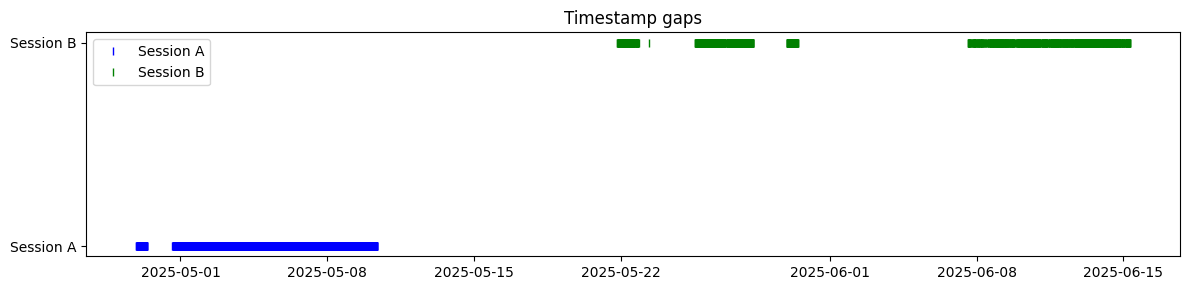

In [5]:
# Load up data for plotting function
sessions = [('Session A', sesh_a, 'blue', 1), ('Session B', sesh_b, 'green', 2)]

plt.figure(figsize=(12,3))
# For each of the values in the session data, create a plot based on those variables
for label, df, color, y in sessions:
    plt.plot(df['Timestamp'], [y] * len(df), '|', color=color, label=label)

plt.yticks([1,2], [s[0] for s in sessions])
plt.title("Timestamp gaps")
plt.legend()
plt.tight_layout()
plt.show()


In session A there is a single gap between `April 29th at 10:05AM` to the `April 30th at 2:49PM`. Being that the first sample was on `April 28th`, it would be ideal to use the `bfill()` method to populate the missing values.

To fill in the gaps, we will need to create an index which will follow the 10 minute spaces between pings. Applying this newly created index to the dataset will help `bfill` to populate it.



In [6]:
# Sort the dataset by Timestamp to follow time series
ind_sesh_a = sesh_a.sort_values('Timestamp')
# Set the index for Timestamp
ind_sesh_a = ind_sesh_a.set_index('Timestamp')
# Apply a 10 minute frequency to the data
ind_sesh_a = ind_sesh_a.asfreq('10min')
ind_sesh_a


,MAC,Temperature,Moisture,Light,Conductivity
Timestamp,,,,,
2025-04-28 21:10:00,c4:7c:8d:6d:26:c9,26.1,11.0,245.0,14.0
2025-04-28 21:20:00,NaN,NaN,NaN,NaN,NaN
2025-04-28 21:30:00,NaN,NaN,NaN,NaN,NaN
2025-04-28 21:40:00,c4:7c:8d:6d:26:c9,26.0,11.0,228.0,11.0
2025-04-28 21:50:00,c4:7c:8d:6d:26:c9,25.8,11.0,261.0,12.0
...,...,...,...,...,...
2025-05-10 08:50:00,c4:7c:8d:6d:26:c9,24.4,12.0,923.0,16.0
2025-05-10 09:00:00,c4:7c:8d:6d:26:c9,24.2,12.0,968.0,17.0
2025-05-10 09:10:00,c4:7c:8d:6d:26:c9,24.1,12.0,889.0,17.0


This data is now ready to be backfilled.

In [7]:
ind_sesh_a = ind_sesh_a.bfill()
# ind_sesh_a

That should be all that is needed to fill the gap from Session A.

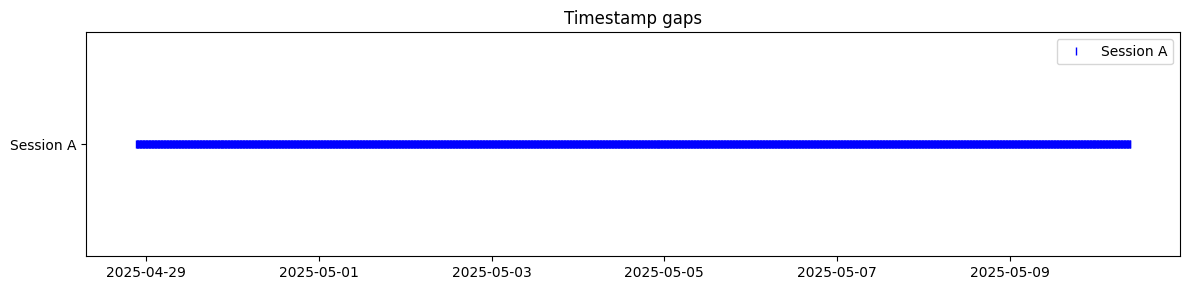

In [8]:
# Plot newly filled session A
sessions = [('Session A', ind_sesh_a, 'blue', 1)]

plt.figure(figsize=(12, 3))

for label, df, color, y in sessions:
    plt.plot(df.index, [y] * len(df), '|', color=color, label=label)

plt.yticks([1], [s[0] for s in sessions])
plt.title("Timestamp gaps")
plt.legend()
plt.tight_layout()
plt.show()


Now let's check out session B.

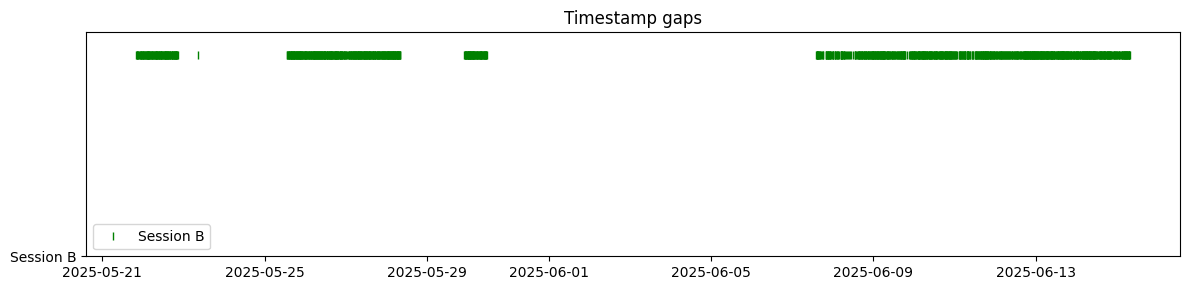

In [9]:
# Load up data for plotting function
sessions = [('Session B', sesh_b, 'green', 2)]

plt.figure(figsize=(12,3))
# For each of the values in the session data, create a plot based on those variables
for label, df, color, y in sessions:
    plt.plot(df['Timestamp'], [y] * len(df), '|', color=color, label=label)

plt.yticks([1], [s[0] for s in sessions])
plt.title("Timestamp gaps")
plt.legend()
plt.tight_layout()
plt.show()

For this we can use `ffill()`. Repeating the same indexing process as before.

In [10]:
# Sort the dataset by Timestamp to follow time series
ind_sesh_b = sesh_b.sort_values('Timestamp')
# Set the index for Timestamp
ind_sesh_b = ind_sesh_b.set_index('Timestamp')
# Apply a 10 minute frequency to the data
ind_sesh_b = ind_sesh_b.asfreq('10min')
ind_sesh_b

,MAC,Temperature,Moisture,Light,Conductivity
Timestamp,,,,,
2025-05-21 20:00:00,c4:7c:8d:6d:26:c9,9.6,27.0,150.0,1600.0
2025-05-21 20:10:00,NaN,NaN,NaN,NaN,NaN
2025-05-21 20:20:00,NaN,NaN,NaN,NaN,NaN
2025-05-21 20:30:00,c4:7c:8d:6d:26:c9,9.3,27.0,0.0,1585.0
2025-05-21 20:40:00,c4:7c:8d:6d:26:c9,9.2,27.0,220.0,1564.0
...,...,...,...,...,...
2025-06-15 07:10:00,c4:7c:8d:6d:26:c9,15.1,25.0,1060.0,626.0
2025-06-15 07:20:00,c4:7c:8d:6d:26:c9,15.1,25.0,1359.0,625.0
2025-06-15 07:30:00,NaN,NaN,NaN,NaN,NaN


In [11]:
ind_sesh_b = ind_sesh_b.ffill()

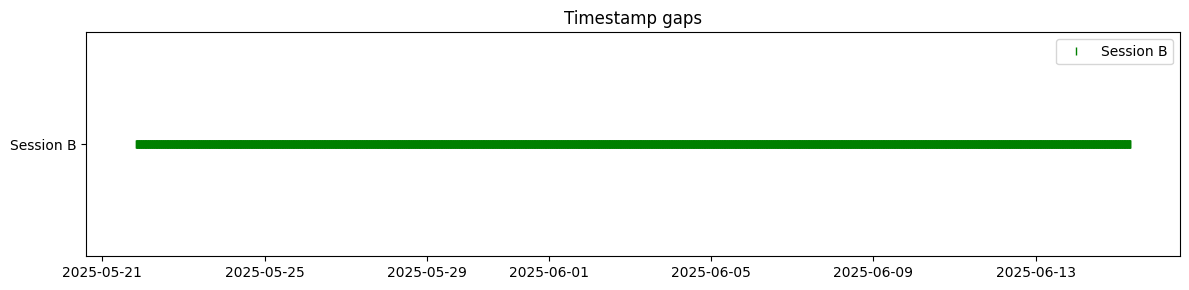

In [12]:
# Plot newly filled session A
sessions = [('Session B', ind_sesh_b, 'green', 1)]

plt.figure(figsize=(12, 3))

for label, df, color, y in sessions:
    plt.plot(df.index, [y] * len(df), '|', color=color, label=label)

plt.yticks([1], [s[0] for s in sessions])
plt.title("Timestamp gaps")
plt.legend()
plt.tight_layout()
plt.show()

Now plotting them together should show both datasets fully populated. Next forward fill can help again in populating the missing data from the last recorded sample in session A to the beginning of session B.

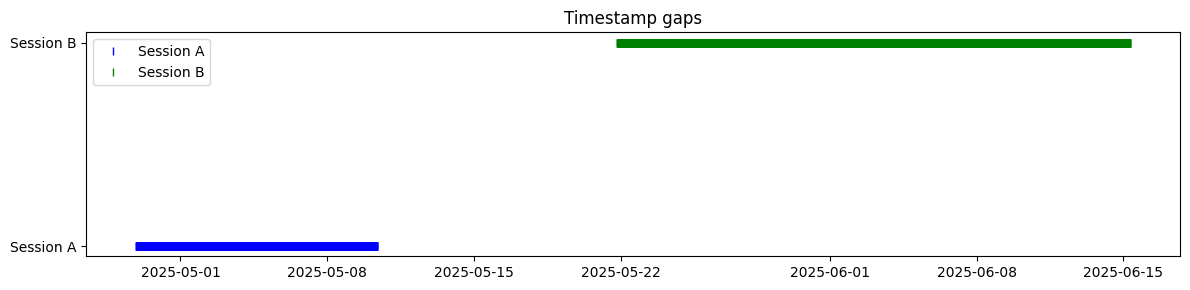

In [13]:
# Plot newly filled session A
sessions = [('Session A', ind_sesh_a, 'blue', 1), ('Session B', ind_sesh_b, 'green', 2)]

plt.figure(figsize=(12, 3))

for label, df, color, y in sessions:
    plt.plot(df.index, [y] * len(df), '|', color=color, label=label)

plt.yticks([1,2], [s[0] for s in sessions])
plt.title("Timestamp gaps")
plt.legend()
plt.tight_layout()
plt.show()

For the sake of not having collected any data between 5/10 through 5/21, we will forward fill session A to 5/21. This involves splitting the dataframe in two and forward filling on the first part.

In [14]:
cutoff = pd.Timestamp('2025-05-21')

# Update index to extend and include cuttoff
full_index = pd.date_range(
    start=ind_sesh_a.index.min(),
    end=cutoff,
    freq='10min'
)

# Reindexing is changing the row labels to match the new index
ind_sesh_a = ind_sesh_a.reindex(full_index).ffill()

Let's check it one more time.

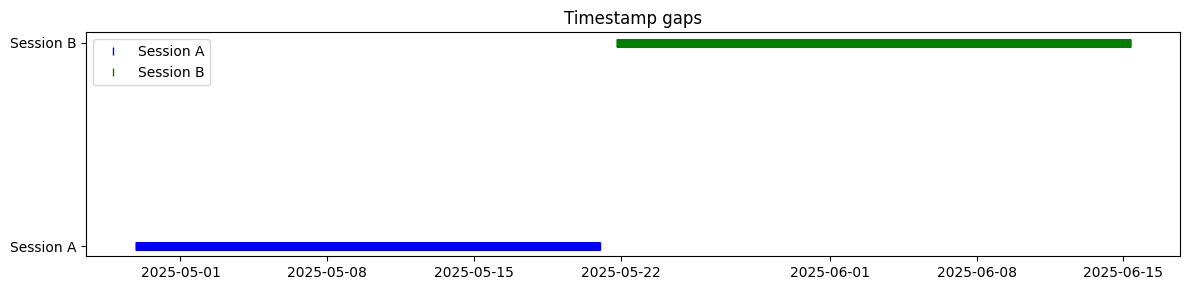

In [15]:
# Plot newly filled session A
sessions = [('Session A', ind_sesh_a, 'blue', 1), ('Session B', ind_sesh_b, 'green', 2)]

plt.figure(figsize=(12, 3))

for label, df, color, y in sessions:
    plt.plot(df.index, [y] * len(df), '|', color=color, label=label)

plt.yticks([1,2], [s[0] for s in sessions])
plt.title("Timestamp gaps")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Applying the changes
sesh_a = ind_sesh_a
sesh_b = ind_sesh_b
sesh_b.isna().sum().sum()


np.int64(0)

<small>© Wiggle Labs 2025<small>